<a href="https://colab.research.google.com/github/Venni2911/LogicMojo-AI-ML-Sept25-VenniRaj/blob/main/Deep_Learning_Implementation_Logic_mojo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Import libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target



In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y
                                                    )

In [ ]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [ ]:
### MLP using sklearn

mlp = MLPClassifier (

                     hidden_layer_sizes = (64,16),
                     activation = 'relu',
                     solver = 'adam',
                     batch_size = 16,
                     max_iter = 10,
                     warm_start = True,
                     random_state = 42


)

In [ ]:
train_loss = []
val_loss = []

for epoch in range(150):
  mlp.fit(X_train, y_train)
  train_loss.append(mlp.loss_)

  y_val_prob = mlp.predict_proba(X_test)[:,1]
  val = -np.mean(y_test * np.log (y_val_prob + 1e-9) + (1-y_test)*np.log (1-y_val_prob + 1e-9))
  val_loss.append(val)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

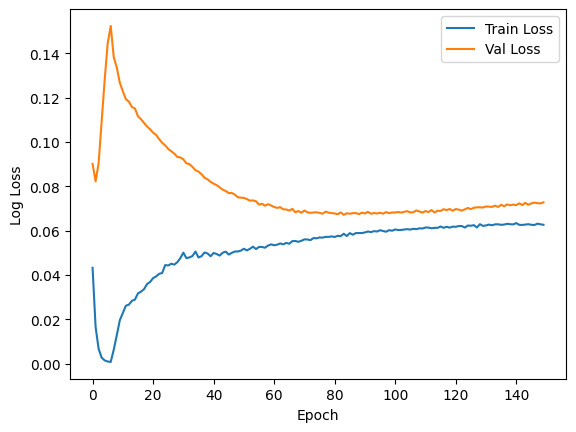

In [ ]:
plt.figure()
plt.plot(train_loss, label = 'Train Loss')
plt.plot ( val_loss, label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

In [ ]:
### Tensorflow


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential ([
    Dense(32, activation = 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation = 'relu'),
    Dropout(0.1),
    Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss ='binary_crossentropy',
    metrics = ['accuracy']

    )

model.summary()


early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10 ,
    restore_best_weights = True
)

history = model.fit( X_train, y_train, validation_split = 0.2, epochs = 150, batch_size = 16, callbacks = [early_stop], verbose = 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6782 - loss: 0.5520 - val_accuracy: 0.7692 - val_loss: 0.4532
Epoch 2/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8376 - loss: 0.3791 - val_accuracy: 0.8901 - val_loss: 0.3327
Epoch 3/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8916 - loss: 0.2977 - val_accuracy: 0.9451 - val_loss: 0.2389
Epoch 4/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9436 - loss: 0.2102 - val_accuracy: 0.9451 - val_loss: 0.1778
Epoch 5/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9534 - loss: 0.1561 - val_accuracy: 0.9560 - val_loss: 0.1360
Epoch 6/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9762 - loss: 0.1316 - val_accuracy: 0.9560 - val_loss: 0.1100
Epoch 7/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9722 - loss: 0.1129 - val_accuracy: 0.9560 - val_loss: 0.0971
Epoch 8/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9807 - loss: 0.1123 - val_accuracy: 0.9780 - 

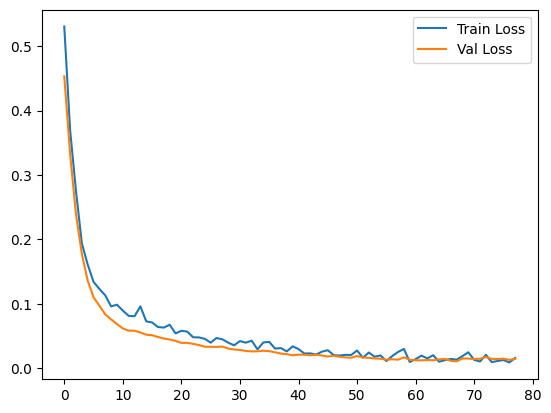

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel = 'Epoch'
plt.ylabel = 'Log Loss'
plt.legend()
plt.show()

In [ ]:
### Hyper parameter tuning

#### 1. No of layers
#### 2. No of neurons
#### 3. Learning rate
#### 4. Optimizers


1. Grid Search CV
2. Random Search CV
3. keras_tuner



In [ ]:
import tensorflow as tf
import tensorflow as keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
import keras_tuner as kt

ModuleNotFoundError: No module named 'keras_tuner'

In [ ]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.5 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import datasets

In [ ]:
### MNIST -> Numerical image classification

(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0


In [ ]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_train = X_train.reshape (-1, 28 * 28)
X_test = X_test.reshape (-1, 28 * 28)



In [ ]:
## create a function that will use keras tuner to check all possible combinations of hyperparameters and provide the best combination

def build_model (hp):
  model = Sequential()

  num_layers = hp.Int('num_layers', min_value =1, max_value = 4) # No of layers

  for i in range(num_layers):
    model.add (layers.Dense (
        units = hp.Int( f"units_{i}", min_value = 32, max_value = 256, step = 8 ), activation = 'relu'
    #model.add (layers.Dropout(0.02))
    ))

  model.add(layers.Dense(10, activation = 'softmax'))

  learning_rate = hp.Choice("learning_rate", [0.01, 0.02, 0.003])

  optimizer_name = hp.Choice("optimizer", ['adam','sgd','rmsprop'])

  if optimizer_name == 'adam':
    optimizer = keras.optimizers.Adam(learning_rate)

  elif optimizer_name == 'sgd':
    optimizer = keras.optimizers.SGD(learning_rate)

  else:
    optimizer = keras.optimizers.RMSprop(learning_rate)

  model.compile (
      optimizer = optimizer ,
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model






In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective = 'val_accuracy',
    max_trials = 10,
    directory = 'mydir',
    project_name = 'ann_tuner'

)


In [ ]:
tuner.search (X_train, y_train, epochs = 5, batch_size = 32, validation_split = 0.2)

Trial 10 Complete [00h 00m 28s]
val_accuracy: 0.965666651725769

Best val_accuracy So Far: 0.9675833582878113
Total elapsed time: 00h 05m 05s


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials = 1)[0]
best_hp.get('num_layers')

3

In [ ]:
best_hp.get('learning_rate')

0.02

In [ ]:
best_hp.get('optimizer')

'sgd'

In [ ]:
model = tuner.get_best_models(num_models = 1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 216)              │       169,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 240)              │        52,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 32)               │         7,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 10)               │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,682 (897.20 KB)

 Trainable params: 229,682 (897.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs = 10, batch_size = 32, validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9761 - loss: 0.0814 - val_accuracy: 0.9694 - val_loss: 0.1030
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9786 - loss: 0.0705 - val_accuracy: 0.9717 - val_loss: 0.0964
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9841 - loss: 0.0578 - val_accuracy: 0.9731 - val_loss: 0.0987
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9852 - loss: 0.0503 - val_accuracy: 0.9730 - val_loss: 0.0892
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9880 - loss: 0.0445 - val_accuracy: 0.9736 - val_loss: 0.0904
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0348 - val_accuracy: 0.9749 - val_loss: 0.0855
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9916 - loss: 0.0308 - val_accuracy: 0.9758 - val_loss: 0.0868
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.027

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9713 - loss: 0.0923


0.975600004196167

In [ ]:
pred = model.predict (X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
import pandas as pd
df = pd.DataFrame (pred)
df.head()

,0,1,2,3,4,5,6,7,8,9
0,1.282833e-07,1.635785e-07,0.000041,1.371030e-03,7.121025e-11,2.095086e-07,9.295116e-15,9.985636e-01,1.545555e-05,8.641340e-06
1,9.614180e-08,4.490471e-05,0.999941,1.296333e-05,5.459313e-12,5.098642e-10,2.272006e-07,4.398496e-11,4.250430e-07,3.455405e-14
2,3.071844e-06,9.984372e-01,0.000092,7.671601e-07,5.196455e-04,1.618750e-05,1.077530e-04,4.650447e-04,3.571926e-04,5.659264e-07
3,9.999707e-01,7.109612e-08,0.000021,8.546253e-09,4.823283e-08,2.824704e-08,6.482328e-06,4.935289e-07,1.190623e-10,6.790296e-07
4,1.460143e-06,1.716083e-07,0.000006,1.281180e-10,9.994845e-01,1.104106e-09,2.663213e-06,5.677743e-05,7.515624e-08,4.481709e-04


In [ ]:
df['pred_class'] = pred.argmax(axis = 1)
df['true_class'] = y_test
df.head()

,0,1,2,3,4,5,6,7,8,9,pred_class,true_class
0,1.282833e-07,1.635785e-07,0.000041,1.371030e-03,7.121025e-11,2.095086e-07,9.295116e-15,9.985636e-01,1.545555e-05,8.641340e-06,7,7
1,9.614180e-08,4.490471e-05,0.999941,1.296333e-05,5.459313e-12,5.098642e-10,2.272006e-07,4.398496e-11,4.250430e-07,3.455405e-14,2,2
2,3.071844e-06,9.984372e-01,0.000092,7.671601e-07,5.196455e-04,1.618750e-05,1.077530e-04,4.650447e-04,3.571926e-04,5.659264e-07,1,1
3,9.999707e-01,7.109612e-08,0.000021,8.546253e-09,4.823283e-08,2.824704e-08,6.482328e-06,4.935289e-07,1.190623e-10,6.790296e-07,0,0
4,1.460143e-06,1.716083e-07,0.000006,1.281180e-10,9.994845e-01,1.104106e-09,2.663213e-06,5.677743e-05,7.515624e-08,4.481709e-04,4,4


In [ ]:
#### CNN implementation

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
X_train = X_train/255.0
X_test = X_test /255.0

In [ ]:
model = Sequential(
    [
        layers.Conv2D(32,(3,3), activation = 'relu', padding = 'same', input_shape = (32,32,3)),
        layers.MaxPool2D((2,2)),

        layers.Conv2D(64,(3,3), activation = 'relu', padding = 'same'),
        layers.MaxPool2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense (10, activation = 'softmax')
    ]
)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
model.fit(X_train,y_train, epochs = 10, batch_size = 32, validation_split = 0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 90ms/step - accuracy: 0.3986 - loss: 1.6561 - val_accuracy: 0.5977 - val_loss: 1.1618
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 98s 55ms/step - accuracy: 0.6272 - loss: 1.0562 - val_accuracy: 0.6673 - val_loss: 0.9622
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.6929 - loss: 0.8890 - val_accuracy: 0.6872 - val_loss: 0.9131
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.7273 - loss: 0.7817 - val_accuracy: 0.7045 - val_loss: 0.8652
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.7607 - loss: 0.6832 - val_accuracy: 0.7102 - val_loss: 0.8471
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 54ms/step - accuracy: 0.7915 - loss: 0.5922 - val_accuracy: 0.7053 - val_loss: 0.8889
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 58ms/step - accuracy: 0.8153 - loss: 0.5205 - val_accuracy: 0.7062 - val_loss: 0.9290
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.8429 

In [ ]:
loss, acc = model.evaluate (X_test, y_test)
acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7094 - loss: 1.0423


0.7044000029563904

In [ ]:
import numpy as np

In [ ]:
pred = model.predict(X_test)
predicted_classes = np.argmax(pred, axis =1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step


In [ ]:
predicted_classes

array([3, 8, 8, ..., 5, 4, 7])

In [ ]:
### data augmentation

data_aug = Sequential ([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1)

])

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
model = Sequential([

    layers.Input(shape = (28,28,1)),

    data_aug,

    layers.Conv2D(32, (3,3), activation = 'relu',
                  kernel_regularizer = regularizers.l2(0.001)),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation = 'relu',
                  kernel_regularizer = regularizers.l2(0.001)),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),


    layers.Flatten(),

    layers.Dense(128, activation= 'relu',
                  kernel_regularizer = regularizers.l2(0.001)),

    layers.Dropout(0.2),

    layers.Dense(10, activation = 'softmax')

])

In [ ]:
### RNN implememntation along with LSTMs


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
max_features = 10000
maxlen = 200
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data( num_words = max_features)

X_train.shape, y_train.shape

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((25000,), (25000,))

In [ ]:
len(X_train[1])

189

In [ ]:
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen)

In [ ]:
len(X_train[0])

200

In [ ]:
model = keras.Sequential([
    layers.Embedding( input_dim= max_features, output_dim = 128),
    layers.LSTM(64, return_sequences = False),
    layers.Dense(1, activation = 'sigmoid')

])

### 12 -> [0.2, 0..3, -0.4,,,,,,,]

In [ ]:
model.compile (optimizer = 'adam',
                loss = 'binary_crossentropy',
                metrics =['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, batch_size = 32, epochs = 2, validation_split = 0.2)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 247ms/step - accuracy: 0.7440 - loss: 0.5001 - val_accuracy: 0.8460 - val_loss: 0.3620
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.8959 - loss: 0.2707 - val_accuracy: 0.8660 - val_loss: 0.3789


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.8554 - loss: 0.3939


0.8555600047111511

In [ ]:
model2 = keras.Sequential([
    layers.Embedding( input_dim= max_features, output_dim = 128),
    layers.SimpleRNN(64),
    layers.Dense(1, activation = 'sigmoid')

])

In [ ]:
model2.compile (optimizer = 'adam',
                loss = 'binary_crossentropy',
                metrics =['accuracy'])

In [ ]:
test_loss, test_acc = model2.evaluate(X_test, y_test)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.5058 - loss: 0.6977


0.5037999749183655